In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt


In [2]:
def PH(X):
    df = pd.DataFrame(data=X)

    df.to_csv("pointcloud.tsv", sep = '\t', index = False)
    !julia PH.jl 
    with open('PH.json','r') as f:
        dic = json.load(f)
    return dic 

In [9]:
L = 500
for j in range(10):
    print(j)
    with open("knots_jodelle_{}_{}.json".format(L,j), 'r') as f:
        knots = json.load(f)

    with open("unknots_jodelle_{}_{}.json".format(L,j), 'r') as f:
        unknots = json.load(f)
    PH_knots = []
    PH_unknots = []
    for i in range(50):
        PH_knots.append(PH(np.array(knots[str(i)][0])[:-1,1:]))
        PH_unknots.append(PH(np.array(unknots[str(i)][0])[:-1,1:]))        
    with open("knots_jodelle_{}_{}_ph.json".format(L,j), 'w') as f:
        json.dump(PH_knots,f)
    with open("unknots_jodelle_{}_{}_ph.json".format(L,j), 'w') as f:
        json.dump(PH_unknots,f)

0
1
2
3
4
5
6
7
8
9


In [6]:
with open("outputs/knots_jodelle_{}_{}.json".format(L,0), 'r') as f:
    knots = json.load(f)
data = np.array(knots[str(0)][0])[:,1:]

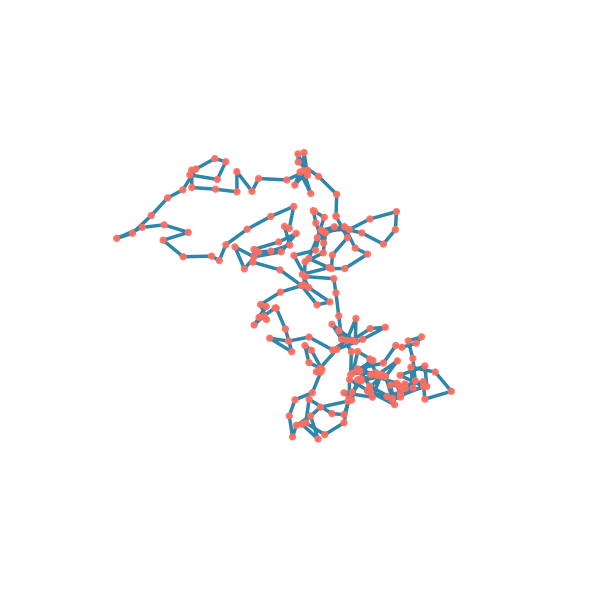

In [7]:
x, y, z = data[:, 0], data[:, 1], data[:, 2]

# Transparent figure (no background)
plt.figure(figsize=(8, 6))
fig = plt.gcf()
fig.patch.set_alpha(0)
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('none')

# 3D curve + points
ax.plot(x, y, z, color='#2E86AB', linewidth=2.5)
ax.scatter(x, y, z, s=18, color='#FF6F61', alpha=0.9)

# Clean style: no panes, no grid
ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.set_edgecolor('none')
    axis.pane.fill = False

# Equal aspect ratio
ranges = [x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]
max_range = max(ranges) if max(ranges) > 0 else 1.0
mid_x, mid_y, mid_z = (x.max()+x.min())/2, (y.max()+y.min())/2, (z.max()+z.min())/2
ax.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
ax.set_ylim(mid_y - max_range/2, mid_y + max_range/2)
ax.set_zlim(mid_z - max_range/2, mid_z + max_range/2)

# Minimal ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_axis_off()
plt.tight_layout()
plt.savefig('3d_curve.png', dpi=300, transparent=True)
